In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/javagarm/fifa-19-complete-player-dataset/kl.csv


In [2]:
import pandas as pd
import numpy as np

players = pd.read_csv(
    '/kaggle/input/datasets/javagarm/fifa-19-complete-player-dataset/kl.csv',
    encoding='cp1252'
)

print(players.shape)
print(players.columns.tolist())

(18207, 89)
['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag', 'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special', 'Preferred Foot', 'International Reputation', 'Weak Foot', 'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position', 'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until', 'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW', 'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM', 'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing', 'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling', 'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration', 'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower', 'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression', 'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure', 'Marking', 'StandingTackle', 'SlidingTackle', 'GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Releas

In [3]:
selected_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                  'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 
                  'Value', 'Position']

print(players[selected_cols].head(10))
print(players[selected_cols].dtypes)
print(players[selected_cols].isnull().sum())

   Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  Stamina  \
0       95.0          90.0       97.0         86.0      59.0     72.0   
1       94.0          81.0       88.0         91.0      79.0     88.0   
2       87.0          84.0       96.0         90.0      49.0     81.0   
3       13.0          50.0       18.0         58.0      64.0     43.0   
4       82.0          92.0       86.0         76.0      75.0     90.0   
5       84.0          89.0       95.0         88.0      66.0     83.0   
6       72.0          93.0       90.0         72.0      58.0     89.0   
7       93.0          82.0       87.0         75.0      83.0     90.0   
8       60.0          78.0       63.0         75.0      83.0     84.0   
9       11.0          29.0       12.0         60.0      78.0     41.0   

   Interceptions  StandingTackle    Value Position  
0           22.0            28.0  €110.5M       RF  
1           29.0            31.0     €77M       ST  
2           36.0            24.0  €11

In [4]:
# نشوف الصفوف اللي فيها قيم فاضية في الأعمدة الرقمية
missing_stats = players[players['Finishing'].isnull()]
print(missing_stats[['Name', 'Position', 'Value']].head(10))

# نشوف هل عمود Value فيه صيغ تانية غير "M"
print(players['Value'].str.contains('K', na=False).sum())
print(players[players['Value'] == '€0']['Value'].count())

# نشوف عينة من القيم الفريدة الغريبة (آخر حروف مختلفة)
print(players['Value'].str[-1].value_counts())

               Name Position  Value
13236    J. McNulty      NaN  €120K
13237    J. Barrera      NaN  €300K
13238      J. Stead      NaN  €140K
13239   A. Semprini      NaN  €425K
13240    R. Bingham      NaN  €400K
13241  K. Dankowski      NaN  €425K
13242     I. Colman      NaN  €450K
13243     M. Feeney      NaN  €600K
13244      R. Minor      NaN  €230K
13245        Klauss      NaN  €425K
11108
0
Value
K    11108
M     6847
0      252
Name: count, dtype: int64


In [5]:
# نتأكد: هل كل الـ48 صف اللي فيها قيم فاضية في Finishing، برضه Position فاضي عندها؟
missing_stats_idx = players[players['Finishing'].isnull()].index
missing_position_idx = players[players['Position'].isnull()].index

print(f"عدد صفوف فاضية في الإحصائيات: {len(missing_stats_idx)}")
print(f"عدد صفوف فاضية في Position: {len(missing_position_idx)}")
print(f"هل كل الـ48 موجودين جوه الـ60؟ {set(missing_stats_idx).issubset(set(missing_position_idx))}")

عدد صفوف فاضية في الإحصائيات: 48
عدد صفوف فاضية في Position: 60
هل كل الـ48 موجودين جوه الـ60؟ True


In [7]:
def parse_value(value_str):
    """
    تحول نص القيمة المالية زي '€110.5M' أو '€425K' أو '€0' لرقم فعلي بالمليون يورو
    """
    value_str = value_str.replace('€', '')
    if value_str.endswith('M'):
        return float(value_str.replace('M', ''))
    elif value_str.endswith('K'):
        return float(value_str.replace('K', '')) / 1000  # نحول الآلاف لمليون عشان الوحدة تتوحد
    else:
        return float(value_str)  # حالة '€0'

# نطبق الدالة على عمود Value
players['Value_numeric'] = players['Value'].apply(parse_value)

# التنضيف النهائي: نشيل أي صف فيه Position فاضي (وده هيشيل الـ48 صف الرقمية كمان تلقائيًا)
selected_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                  'Strength', 'Stamina', 'Interceptions', 'StandingTackle']

players_clean = players.dropna(subset=['Position'] + selected_cols).copy()

print(players.shape, '->', players_clean.shape)
print(players_clean['Value_numeric'].describe())

(18207, 90) -> (18147, 90)
count    18147.000000
mean         2.417729
std          5.602826
min          0.000000
25%          0.300000
50%          0.675000
75%          2.000000
max        118.500000
Name: Value_numeric, dtype: float64


In [8]:
feature_cols = ['Finishing', 'ShortPassing', 'Dribbling', 'SprintSpeed', 
                 'Strength', 'Stamina', 'Interceptions', 'StandingTackle', 
                 'Value_numeric']

X = players_clean[feature_cols].reset_index(drop=True)
positions = players_clean['Position'].reset_index(drop=True)
names = players_clean['Name'].reset_index(drop=True)

print(X.shape)
print(X.head())
print(positions.value_counts())

(18147, 9)
   Finishing  ShortPassing  Dribbling  SprintSpeed  Strength  Stamina  \
0       95.0          90.0       97.0         86.0      59.0     72.0   
1       94.0          81.0       88.0         91.0      79.0     88.0   
2       87.0          84.0       96.0         90.0      49.0     81.0   
3       13.0          50.0       18.0         58.0      64.0     43.0   
4       82.0          92.0       86.0         76.0      75.0     90.0   

   Interceptions  StandingTackle  Value_numeric  
0           22.0            28.0          110.5  
1           29.0            31.0           77.0  
2           36.0            24.0          118.5  
3           30.0            21.0           72.0  
4           61.0            58.0          102.0  
Position
ST     2152
GK     2025
CB     1778
CM     1394
LB     1322
RB     1291
RM     1124
LM     1095
CAM     958
CDM     948
RCB     662
LCB     648
LCM     395
RCM     391
LW      381
RW      370
RDM     248
LDM     243
LS      207
RS      203
R

In [9]:
X_mean = X.mean()
X_std = X.std()

X_standardized = (X - X_mean) / X_std

print(X_standardized.mean())   # المفروض قريبة جدًا من صفر لكل عمود
print(X_standardized.std())    # المفروض قريبة جدًا من 1 لكل عمود
print(X_standardized.head())

Finishing         8.770682e-17
ShortPassing      1.002364e-16
Dribbling        -1.754136e-16
SprintSpeed      -3.132387e-17
Strength         -5.011818e-16
Stamina           1.503546e-16
Interceptions    -1.002364e-16
StandingTackle    3.758864e-17
Value_numeric    -1.252955e-16
dtype: float64
Finishing         1.0
ShortPassing      1.0
Dribbling         1.0
SprintSpeed       1.0
Strength          1.0
Stamina           1.0
Interceptions     1.0
StandingTackle    1.0
Value_numeric     1.0
dtype: float64
   Finishing  ShortPassing  Dribbling  SprintSpeed  Strength   Stamina  \
0   2.532322      2.130131   2.200949     1.451958 -0.503376  0.552228   
1   2.481112      1.517723   1.725066     1.793214  1.089934  1.558746   
2   2.122642      1.721859   2.148073     1.724963 -1.300032  1.118394   
3  -1.666896     -0.591684  -1.976243    -0.459073 -0.105049 -1.272087   
4   1.866592      2.266222   1.619315     0.769447  0.771272  1.684561   

   Interceptions  StandingTackle  Value_numeric 

In [10]:
# نستخدم log1p (log(1+x)) عشان نتجنب مشكلة log(0) للاعبين قيمتهم صفر
X['Value_numeric'] = np.log1p(X['Value_numeric'])

# نعيد الـ standardization تاني بعد التحويل
X_standardized = (X - X.mean()) / X.std()

print(X_standardized['Value_numeric'].describe())
print(X_standardized.head())

count    1.814700e+04
mean    -1.252955e-17
std      1.000000e+00
min     -1.049629e+00
25%     -7.051604e-01
50%     -3.723973e-01
75%      3.927828e-01
max      5.230577e+00
Name: Value_numeric, dtype: float64
   Finishing  ShortPassing  Dribbling  SprintSpeed  Strength   Stamina  \
0   2.532322      2.130131   2.200949     1.451958 -0.503376  0.552228   
1   2.481112      1.517723   1.725066     1.793214  1.089934  1.558746   
2   2.122642      1.721859   2.148073     1.724963 -1.300032  1.118394   
3  -1.666896     -0.591684  -1.976243    -0.459073 -0.105049 -1.272087   
4   1.866592      2.266222   1.619315     0.769447  0.771272  1.684561   

   Interceptions  StandingTackle  Value_numeric  
0      -1.193516       -0.909445       5.139601  
1      -0.855311       -0.770964       4.670467  
2      -0.517105       -1.094086       5.230577  
3      -0.806996       -1.232567       4.583485  
4       0.690773        0.475365       5.035490  


Value_numeric required a log1p transformation prior to standardization, as its raw distribution was heavily right-skewed (a small number of star players carry disproportionately high market values), which would have caused this single feature to dominate the PCA's variance structure

In [11]:
X_matrix = X_standardized.values   # نحولها لـ numpy array عادي

n_samples = X_matrix.shape[0]

# صيغة الـ covariance matrix: (1/(n-1)) * X^T . X  (لأن البيانات standardized بالفعل، متوسطها صفر)
cov_matrix = (X_matrix.T @ X_matrix) / (n_samples - 1)

print(cov_matrix.shape)   # المفروض يبقى 9×9 (عدد الفيتشرز × عدد الفيتشرز)
print(cov_matrix)

(9, 9)
[[ 1.          0.66207808  0.82439041  0.59399654 -0.00950254  0.51087999
  -0.02048107 -0.03282832  0.3614981 ]
 [ 0.66207808  1.          0.84386231  0.55510199  0.13363796  0.71688155
   0.54358506  0.5413476   0.47917157]
 [ 0.82439041  0.84386231  1.          0.72695289 -0.03361414  0.68647454
   0.29612143  0.30132938  0.39926536]
 [ 0.59399654  0.55510199  0.72695289  1.         -0.08317251  0.61997348
   0.16422492  0.17838949  0.25819481]
 [-0.00950254  0.13363796 -0.03361414 -0.08317251  1.          0.26277501
   0.35638288  0.33198975  0.2187577 ]
 [ 0.51087999  0.71688155  0.68647454  0.61997348  0.26277501  1.
   0.57661549  0.57026306  0.32851823]
 [-0.02048107  0.54358506  0.29612143  0.16422492  0.35638288  0.57661549
   1.          0.94145594  0.23432288]
 [-0.03282832  0.5413476   0.30132938  0.17838949  0.33198975  0.57026306
   0.94145594  1.          0.18786617]
 [ 0.3614981   0.47917157  0.39926536  0.25819481  0.2187577   0.32851823
   0.23432288  0.187866

In [12]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors shape:", eigenvectors.shape)

Eigenvalues:
[4.44247764 1.99991255 0.96166071 0.6639488  0.43954725 0.12759881
 0.08095839 0.05599641 0.22789944]

Eigenvectors shape: (9, 9)


In [13]:
# نرتب الـ indices تنازليًا حسب حجم الـ eigenvalue
sorted_idx = np.argsort(eigenvalues)[::-1]

eigenvalues_sorted = eigenvalues[sorted_idx]
eigenvectors_sorted = eigenvectors[:, sorted_idx]   # لازم نرتب الأعمدة (مش الصفوف) لأن كل عمود = eigenvector كامل

print("Sorted eigenvalues:")
print(eigenvalues_sorted)

# نحسب نسبة التباين اللي كل component بيفسرها
explained_variance_ratio = eigenvalues_sorted / eigenvalues_sorted.sum()
print("\nExplained variance ratio:")
print(explained_variance_ratio)

# ونسبة تراكمية عشان نشوف أول 2 components بيفسروا كام % مجتمعين
print("\nCumulative explained variance:")
print(np.cumsum(explained_variance_ratio))

Sorted eigenvalues:
[4.44247764 1.99991255 0.96166071 0.6639488  0.43954725 0.22789944
 0.12759881 0.08095839 0.05599641]

Explained variance ratio:
[0.49360863 0.22221251 0.10685119 0.07377209 0.04883858 0.02532216
 0.01417765 0.00899538 0.00622182]

Cumulative explained variance:
[0.49360863 0.71582113 0.82267232 0.89644441 0.94528299 0.97060515
 0.9847828  0.99377818 1.        ]


In [14]:
# ناخد أول 2 عمود بس من الـ eigenvectors المرتبة (أول 2 principal components)
top_2_eigenvectors = eigenvectors_sorted[:, :2]

# الـ Projection: الداتا الـ standardized مضروبة في مصفوفة الـ eigenvectors المختارة
X_pca = X_matrix @ top_2_eigenvectors

print(X_pca.shape)   # المفروض يبقى (18147, 2)
print(X_pca[:5])

# نحولها لـ DataFrame مرتب مع الـ Position عشان نجهزها للرسم
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Position'] = positions
pca_df['Name'] = names

print(pca_df.head())

(18147, 2)
[[-3.99297394 -3.52736607]
 [-4.23939524 -2.51321028]
 [-4.06632379 -3.43172532]
 [ 1.76321064  0.09278574]
 [-4.91294303 -0.67383931]]
        PC1       PC2 Position               Name
0 -3.992974 -3.527366       RF           L. Messi
1 -4.239395 -2.513210       ST  Cristiano Ronaldo
2 -4.066324 -3.431725       LW          Neymar Jr
3  1.763211  0.092786       GK             De Gea
4 -4.912943 -0.673839      RCM       K. De Bruyne


In [15]:
def categorize_position(pos):
    if pos == 'GK':
        return 'Goalkeeper'
    elif pos in ['CB', 'LCB', 'RCB', 'LB', 'RB', 'LWB', 'RWB']:
        return 'Defender'
    elif pos in ['CDM', 'CM', 'LCM', 'RCM', 'LDM', 'RDM', 'LM', 'RM', 'CAM', 'LAM', 'RAM']:
        return 'Midfielder'
    else:  # ST, RS, LS, RW, LW, CF, RF, LF
        return 'Attacker'

pca_df['Position_Category'] = pca_df['Position'].apply(categorize_position)

print(pca_df['Position_Category'].value_counts())

Position_Category
Midfielder    6838
Defender      5866
Attacker      3418
Goalkeeper    2025
Name: count, dtype: int64


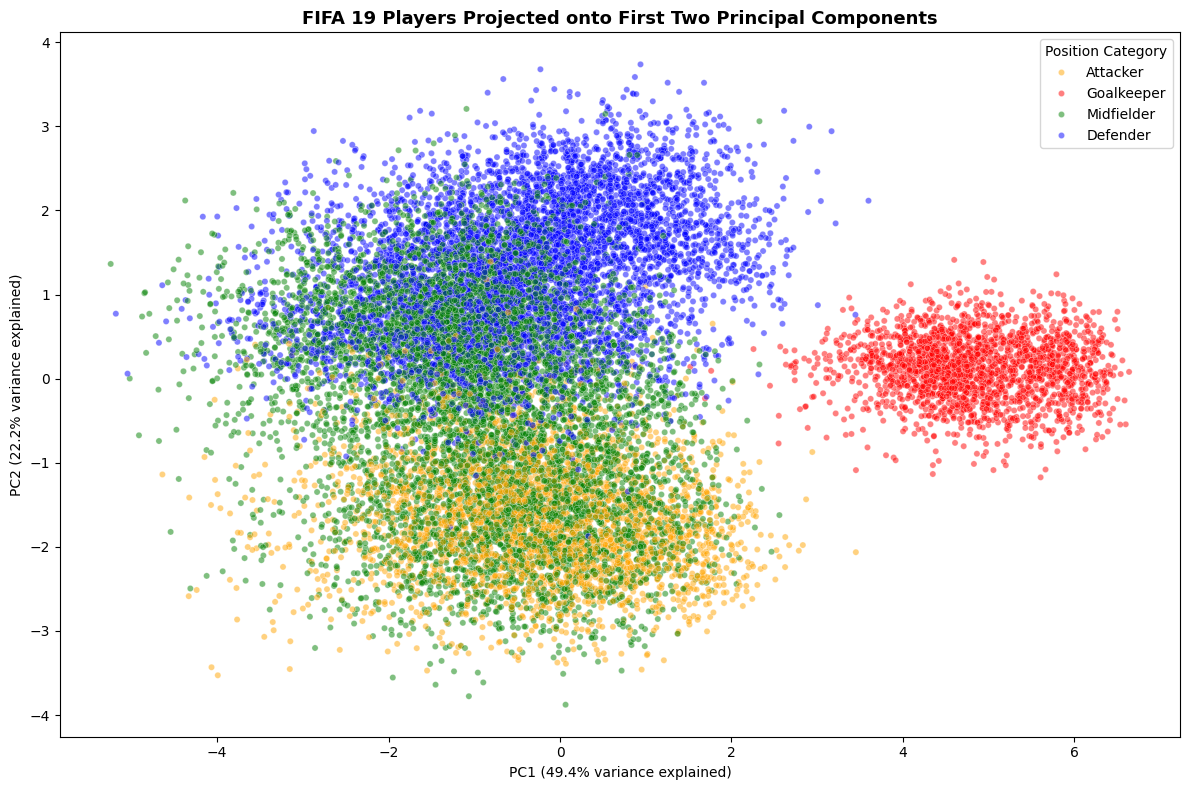

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Position_Category',
    palette={'Goalkeeper': 'red', 'Defender': 'blue', 'Midfielder': 'green', 'Attacker': 'orange'},
    alpha=0.5,
    s=20,
    ax=ax
)

ax.set_xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance explained)')
ax.set_ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance explained)')
ax.set_title('FIFA 19 Players Projected onto First Two Principal Components', fontsize=13, fontweight='bold')
ax.legend(title='Position Category')

plt.tight_layout()
plt.savefig('pca_scatter.png', dpi=150)
plt.show()

Despite being derived purely from numerical performance statistics with no explicit knowledge of player positions, the first two principal components alone (71.6% of total variance) successfully recover the traditional football role hierarchy: goalkeepers separate almost perfectly along PC1, while PC2 captures a clear defensive-to-attacking spectrum, with midfielders correctly occupying the transitional middle ground. This validates that the 9 selected features capture meaningful, position-relevant structure in player performance

# bouns

In [17]:
# ناخد عينة أصغر للاختبار الأولي (Pure Python هيبقى بطيء جدًا على 18147 صف، هنتأكد الأول إنه شغال صح)
X_list = X.values.tolist()   # X هي نفس DataFrame الأصلي (قبل الـ standardization)، غير مُعدّلة

print(len(X_list))          # عدد الصفوف (اللاعبين)
print(len(X_list[0]))       # عدد الأعمدة (الفيتشرز)
print(X_list[0])            # أول لاعب كمثال

18147
9
[95.0, 90.0, 97.0, 86.0, 59.0, 72.0, 22.0, 28.0, 4.7140245909001735]


In [18]:
def transpose(matrix):
    """
    تاخد matrix (list of lists) وترجع الـ transpose بتاعتها
    """
    rows = len(matrix)
    cols = len(matrix[0])
    result = [[matrix[r][c] for r in range(rows)] for c in range(cols)]
    return result

# اختبار سريع على مثال بسيط
test_matrix = [[1, 2, 3], [4, 5, 6]]
print(transpose(test_matrix))   # المفروض يطلع [[1, 4], [2, 5], [3, 6]]

[[1, 4], [2, 5], [3, 6]]


In [19]:
def multiply_matrices(A, B):
    """
    تضرب مصفوفتين A و B (list of lists) وترجع الناتج
    شرط: عدد أعمدة A لازم يساوي عدد صفوف B
    """
    rows_A = len(A)
    cols_A = len(A[0])
    rows_B = len(B)
    cols_B = len(B[0])
    
    if cols_A != rows_B:
        raise ValueError("عدد أعمدة A لازم يساوي عدد صفوف B")
    
    # نجهز مصفوفة النتيجة بأصفار الأول
    result = [[0 for _ in range(cols_B)] for _ in range(rows_A)]
    
    for i in range(rows_A):
        for j in range(cols_B):
            total = 0
            for k in range(cols_A):
                total += A[i][k] * B[k][j]
            result[i][j] = total
    
    return result

# اختبار سريع
A_test = [[1, 2], [3, 4]]
B_test = [[5, 6], [7, 8]]
print(multiply_matrices(A_test, B_test))
# المفروض يطلع [[19, 22], [43, 50]]
# (1*5 + 2*7 = 19), (1*6 + 2*8 = 22), (3*5 + 4*7 = 43), (3*6 + 4*8 = 50)

[[19, 22], [43, 50]]


In [20]:
def standardize_data(matrix):
    """
    تاخد matrix (list of lists)، وترجع نسخة معيارية (Z-score) منها
    بتحسب المتوسط والانحراف المعياري لكل عمود على حدة
    """
    rows = len(matrix)
    cols = len(matrix[0])
    
    standardized = [[0.0 for _ in range(cols)] for _ in range(rows)]
    
    for c in range(cols):
        # نجمع كل قيم العمود ده
        column_values = [matrix[r][c] for r in range(rows)]
        
        # المتوسط
        mean = sum(column_values) / rows
        
        # الانحراف المعياري (sample std، ddof=1 زي pandas عشان نفس المنطق المتبع فوق)
        variance = sum((x - mean) ** 2 for x in column_values) / (rows - 1)
        std = variance ** 0.5
        
        # نطبق الـ Z-score على كل قيمة في العمود
        for r in range(rows):
            standardized[r][c] = (matrix[r][c] - mean) / std
    
    return standardized

# اختبار على عينة صغيرة من الداتا الحقيقية (أول 5 صفوف بس، عشان نتأكد بسرعة)
sample = X_list[:5]
standardized_sample = standardize_data(sample)
for row in standardized_sample:
    print(row)

[0.6007697851056762, 0.6226681828843795, 0.6000300022501875, 0.42166487700417105, -0.5110198668817352, -0.14641836440507047, -0.9040587031569725, -0.29712100860230317, 0.7199696849442994]
[0.571886622360211, 0.09398765024669851, 0.3300165012376032, 0.7851690813181118, 1.1374313166077323, 0.6902580036239045, -0.4387343706497073, -0.09453850273709641, -0.9064147072548524]
[0.3697044831419546, 0.2702144944592588, 0.5700285021376782, 0.7124682404553236, -1.3352454586264688, 0.32421209261122796, 0.026589961857557916, -0.5672310164225789, 1.0353631871463072]
[-1.7676495600224709, -1.7270230732830916, -1.7700885066380532, -1.613958667153897, -0.09890707100936828, -1.6628942814575878, -0.3722594660058122, -0.7698135222877857, -1.207960223655559]
[0.22528866941462855, 0.7401527456927531, 0.2700135010125844, -0.3053435316237104, 0.8077410799098388, 0.7948425496275264, 1.6884625779549336, 1.7287040500497646, 0.35904205881979695]


In [21]:
def covariance_matrix_pure(standardized_matrix):
    """
    تحسب الـ covariance matrix من بيانات معيارية بالفعل
    باستخدام دوال transpose و multiply_matrices اللي بنيناها إحنا
    """
    n_samples = len(standardized_matrix)
    
    # transpose للداتا standardized
    X_T = transpose(standardized_matrix)
    
    # الضرب المصفوفي: X^T . X
    XtX = multiply_matrices(X_T, standardized_matrix)
    
    # نقسم كل عنصر على (n-1)
    cov = [[XtX[i][j] / (n_samples - 1) for j in range(len(XtX[0]))] for i in range(len(XtX))]
    
    return cov

In [22]:
def project_data_pure(standardized_matrix, eigenvectors_selected):
    """
    تسقط الداتا المعيارية على الـ eigenvectors المختارة (مثلاً أول 2)
    باستخدام دالة multiply_matrices اللي بنيناها
    """
    return multiply_matrices(standardized_matrix, eigenvectors_selected)

In [23]:
import time

# ناخد عينة صغيرة الأول للتأكد إن كل حاجة شغالة صح قبل ما نشغل على الداتا الكاملة
sample_size = 100
X_sample = X_list[:sample_size]

# 1. Standardize
standardized_sample = standardize_data(X_sample)

# 2. Covariance matrix
cov_sample = covariance_matrix_pure(standardized_sample)

print("Covariance matrix shape:", len(cov_sample), "x", len(cov_sample[0]))
print(cov_sample[0])   # أول صف بس عشان نشوف الأرقام

Covariance matrix shape: 9 x 9
[1.0000000000000002, 0.7988789493080451, 0.8954097128940566, 0.5580613618179885, -0.17357421608768678, 0.7580165071980599, -0.018472486568689203, 0.006235869901568253, 0.4530482964443735]


In [24]:
# 3. Eigen-decomposition (نستخدم numpy هنا، زي ما اتفقنا - مسموح بيه في البونص)
cov_sample_np = np.array(cov_sample)
eigenvalues_sample, eigenvectors_sample = np.linalg.eig(cov_sample_np)

# 4. نرتب تنازليًا
sorted_idx_sample = np.argsort(eigenvalues_sample)[::-1]
eigenvectors_sample_sorted = eigenvectors_sample[:, sorted_idx_sample]

# ناخد أول 2 عمود ونحولهم لـ list of lists عشان نقدر نستخدم دالتنا project_data_pure
top_2_eigenvectors_sample = eigenvectors_sample_sorted[:, :2].tolist()

# 5. Projection باستخدام الدالة اللي بنيناها من الصفر
projected_sample = project_data_pure(standardized_sample, top_2_eigenvectors_sample)

print(len(projected_sample), len(projected_sample[0]))   # المفروض يبقى (100, 2)
print(projected_sample[:5])

100 2
[[-1.630492187367671, -2.9226014805977494], [-1.587474560335685, -1.7753815498863712], [-1.8100253521288654, -3.0197661111731358], [4.2477315707114585, -1.3420522253204916], [-1.9230753414739699, -0.4428209744361059]]


In [25]:
import time

# ============ النسخة الكاملة بـ NumPy ============
start_numpy = time.time()

X_matrix_full = X_standardized.values
cov_numpy = (X_matrix_full.T @ X_matrix_full) / (len(X_matrix_full) - 1)
eigvals_numpy, eigvecs_numpy = np.linalg.eig(cov_numpy)
sorted_idx_numpy = np.argsort(eigvals_numpy)[::-1]
eigvecs_numpy_sorted = eigvecs_numpy[:, sorted_idx_numpy][:, :2]
projected_numpy = X_matrix_full @ eigvecs_numpy_sorted

end_numpy = time.time()
time_numpy = end_numpy - start_numpy
print(f"NumPy pipeline time: {time_numpy:.4f} seconds")

NumPy pipeline time: 0.0037 seconds


In [26]:
# ============ النسخة الكاملة بـ Pure Python ============
start_pure = time.time()

standardized_full = standardize_data(X_list)
cov_full = covariance_matrix_pure(standardized_full)

cov_full_np = np.array(cov_full)   # نستخدم numpy بس لخطوة الـ eigen-decomposition (مسموح بيها)
eigvals_full, eigvecs_full = np.linalg.eig(cov_full_np)
sorted_idx_full = np.argsort(eigvals_full)[::-1]
top_2_eigvecs_full = eigvecs_full[:, sorted_idx_full][:, :2].tolist()

projected_pure = project_data_pure(standardized_full, top_2_eigvecs_full)

end_pure = time.time()
time_pure = end_pure - start_pure
print(f"Pure Python pipeline time: {time_pure:.4f} seconds")

print(f"\nSpeedup factor: {time_pure / time_numpy:.1f}x faster with NumPy")

Pure Python pipeline time: 0.2712 seconds

Speedup factor: 73.7x faster with NumPy


In [27]:
projected_pure_np = np.array(projected_pure)

# نقارن أول 5 صفوف من الاتنين
print("NumPy result (first 5 rows):")
print(projected_numpy[:5])

print("\nPure Python result (first 5 rows):")
print(projected_pure_np[:5])

# نحسب الفرق المطلق بين الاتنين (numerical error)
max_diff = np.max(np.abs(projected_numpy) - np.abs(projected_pure_np))
print(f"\nMax absolute difference: {max_diff}")

NumPy result (first 5 rows):
[[-3.99297394 -3.52736607]
 [-4.23939524 -2.51321028]
 [-4.06632379 -3.43172532]
 [ 1.76321064  0.09278574]
 [-4.91294303 -0.67383931]]

Pure Python result (first 5 rows):
[[-3.99297394 -3.52736607]
 [-4.23939524 -2.51321028]
 [-4.06632379 -3.43172532]
 [ 1.76321064  0.09278574]
 [-4.91294303 -0.67383931]]

Max absolute difference: 2.282618538629322e-13
